# BEoRN: Modelling the 21-cm Signal from the Epoch of Reionization

This notebook demonstrates how to use **BEoRN** to model the 21-cm brightness temperature signal from the Epoch of Reionization (EoR). BEoRN paints astrophysical radiation fields — X-ray heating, Lyman-alpha coupling, and ionization — onto a cosmological density field by placing pre-computed 1D profiles around dark matter halos.

The density fields and halo catalogs are generated here using [py21cmfast](https://github.com/21cmfast/21cmFAST), a semi-numerical simulation code for the EoR. BEoRN then uses these as input to produce full 3D maps of the 21-cm signal.

**Requirements:** Install BEoRN with the optional dependencies (py21cmfast and hmf):
```bash
pip install "git+https://github.com/cosmic-reionization/beorn.git[extra]"
```

**Output:** All results are saved under `./output/` and intermediate cached computations under `./cache/`. Both directories are created automatically.

In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [2]:
FILE_ROOT = Path(".")
CACHE_ROOT = FILE_ROOT / "cache"
OUTPUT_ROOT = FILE_ROOT / "output"

In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 14,
})


INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## 1. Set simulation and astrophysical parameters

Here we define the cosmology, the simulation volume, and the astrophysical source model.

- **Simulation:** box size and grid resolution determine the spatial dynamic range. The redshift array sets the snapshots at which the 21-cm signal is computed.
- **Cosmology:** standard ΛCDM parameters. These must be consistent with the values used by py21cmfast.
- **Source model:** controls star formation efficiency, ionizing photon production, X-ray emission, and Lyman-alpha flux from the first galaxies. These are the key parameters to vary when exploring different reionization histories.

> **Tip:** Start with a coarse grid (`Ncell=64`) for quick exploration, then increase resolution for production runs.

In [4]:
parameters = beorn.structs.Parameters()

## Simulation parameters
parameters.simulation.cores = 4
parameters.simulation.Lbox  = 100       # comoving Mpc/h
parameters.simulation.Ncell = 128
parameters.simulation.py21cmfast_high_res_factor = 3

parameters.simulation.halo_mass_bin_min = 1e7
parameters.simulation.halo_mass_bin_max = 1e15
parameters.simulation.halo_mass_bin_n = 40
parameters.simulation.halo_mass_accretion_alpha = np.array([0.785, 0.795])

## Redshifts — py21cmfast will be run for each of these.
## A range is required (not a single value) because the solver integrates
## bubble growth history from high-z down to the target redshift.
parameters.solver.redshifts = np.arange(18, 5.5, -0.5)

## Cosmology
parameters.cosmology.Om = 0.315
parameters.cosmology.Ob = 0.049
parameters.cosmology.Ol = 1-0.315
parameters.cosmology.h  = 0.673

## Source parameters
# X-ray emission
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray = 200
parameters.source.energy_max_sed_xray = 10000
parameters.source.alS_xray = 1.5
parameters.source.xray_normalisation = 0.3 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690
parameters.source.lyman_alpha_power_law = 0.0

# Ionization
parameters.source.Nion = 2000

# Escape fraction
parameters.source.f0_esc = 0.2
parameters.source.pl_esc = 0.5

# Star formation efficiency
parameters.source.f_st = 0.2
parameters.source.g1 = 0.49
parameters.source.g2 = -0.61
parameters.source.g3 = 4
parameters.source.g4 = -4
parameters.source.Mp = 1.6e11 * parameters.cosmology.h
parameters.source.Mt = 1e9

# Minimum star-forming halo mass
parameters.source.halo_mass_min = 1e8

## 2. Generate the cosmological density field and halo catalogs

We use py21cmfast to produce the raw cosmological inputs: matter density fields and dark matter halo catalogs at each redshift. These encode where and how massive the first collapsed structures are — the seeds of the first galaxies.

This step only needs to run once for a given cosmology, box size, and random seed. If the data already exists from a previous run it will be reused automatically, so you can safely re-run this cell.

In [5]:
loader = beorn.load_input_data.Py21cmFastLoader(parameters)
output_handler = beorn.io.Handler(OUTPUT_ROOT, input_tag=loader.input_tag)

loader.generate(output_handler)

INFO:beorn.io.handler:Using persistence directory at output
INFO:beorn.load_input_data.cosmo_sim_py21cmfast:py21cmfast setup:
  Output directory : output/py21cmfast_N128_D384_L100_seed12345_662d0845
  Grid             : HII_DIM=128, DIM=384 (factor 3x)
  Box size         : 100.0 Mpc/h (148.6 Mpc)
  Threads          : 4
  Random seed      : 12345
  Cosmology        : Om=0.315, Ob=0.049, h=0.673, sigma_8=0.83, ns=0.96
INFO:beorn.load_input_data.cosmo_sim_py21cmfast:All 25 snapshots already cached. Skipping generation.


## 3. Inspect the halo catalog and density field

Before running the full simulation, it is useful to check the input data. The halo mass function describes the abundance of dark matter halos as a function of mass and should match the analytical prediction (Sheth & Tormen 1999) for the given cosmology and redshift. We also show a 2D slice through the matter overdensity field, which reveals the large-scale cosmic web structure.

INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


Number of halos at z=7.0: 320931
Mass range: 1.78e+09 — 9.63e+11 Msol


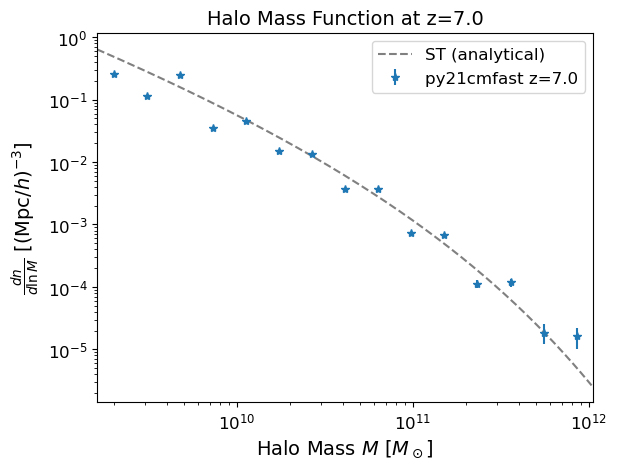

In [6]:
z_target = 7.0
z_index = np.argmin(np.abs(loader.redshifts - z_target))

halo_catalog = loader.load_halo_catalog(z_index)
print(f"Number of halos at z={z_target}: {len(halo_catalog.masses)}")
print(f"Mass range: {halo_catalog.masses.min():.2e} — {halo_catalog.masses.max():.2e} Msol")

# Plot halo mass function from the catalog with analytical Sheth & Tormen (1999) reference
fig, ax = plt.subplots()
beorn.plotting.plot_halo_mass_function(ax, halo_catalog, bin_count=15,
                                       label=f'py21cmfast z={z_target}',
                                       analytical_model='ST')
ax.set_title(f'Halo Mass Function at z={z_target}', fontsize=14)
ax.legend()
plt.show()

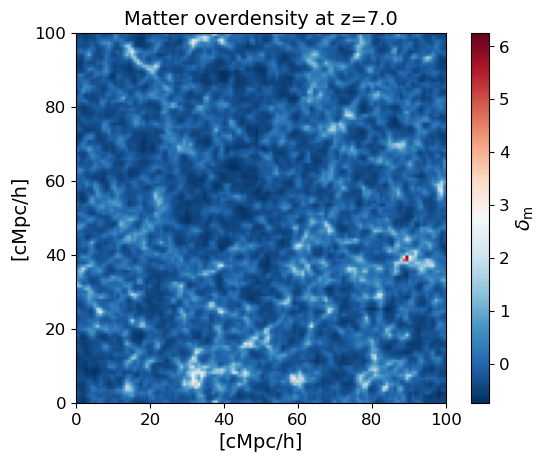

In [7]:
delta_m = loader.load_density_field(z_index)

Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]

plt.figure()
plt.imshow(delta_m[:, delta_m.shape[1] // 2, :], origin='lower', cmap='RdBu_r', extent=extent)
plt.colorbar(label=r'$\delta_\mathrm{m}$')
plt.xlabel('[cMpc/h]')
plt.ylabel('[cMpc/h]')
plt.title(f'Matter overdensity at z={z_target}')
plt.show()

## 4. Precompute radiation profiles

BEoRN pre-computes 1D radial profiles of X-ray heating, Lyman-alpha flux, and ionization around halos of different masses. These profiles capture how radiation from the first galaxies affects the surrounding IGM as a function of distance. Pre-computing them once and caching the result means they can be reused efficiently when painting different realisations or astrophysical models.

In [8]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

solver = beorn.precomputation.RadiationProfileSolver(parameters, loader.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)

INFO:beorn.io.handler:Using persistence directory at cache
INFO:beorn.precomputation.solver:Loaded radiation profiles from cache.


## 5. Paint the 3D signal maps

BEoRN places the pre-computed profiles around each halo in the catalog and accumulates their contributions on the grid. This produces 3D maps of the ionization fraction, gas temperature, and Lyman-alpha coupling at each redshift — the ingredients needed to compute the 21-cm brightness temperature.

Snapshots that have already been computed are skipped automatically, so interrupted runs resume from where they left off.

In [9]:
p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
)

multi_z_quantities = p.paint_full(profiles)

INFO:beorn.painting.coordinator:Setting up 1 painting processes for MPI.
INFO:beorn.painting.coordinator:Submitting 25/25 snapshot(s) to MPI workers.
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting.coordinator:Painting 2 halos at zgrid=18.00 (z_index=0).
INFO:beorn.painting.coordinator:Profile painting took 0:00:03.304249.
INFO:beorn.painting.spread:Universe not fully ionized : xHII is 0.0.
INFO:beorn.painting.coordinator:Redistributing excess photons from the overlapping regions took 0:00:00.026971.
INFO:beorn.painting.coordinator:Postprocessing of the grids took 0:00:00.041422.
INFO:beorn.painting.coordinator:Current snapshot took 0:00:03.389731.
INFO:beorn.structs.base_struct:Data written to output/igm_data_py21cmfast_N128_D384_L100_seed12345_662d0845_aed1b814/CoevalCube_z18.000.h5 (56.02 MB)
INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.
INFO:beorn.painting

## 6. Visualise the 3D maps at a single redshift

We show a 2D slice through the simulation box for the three key fields at the chosen redshift: the ionization fraction $x_\mathrm{HII}$, the gas kinetic temperature $T_k$, and the 21-cm brightness temperature $\delta T_b$. The ionized bubbles visible in the $x_\mathrm{HII}$ map are driven by the same halos that appear in the mass function above.

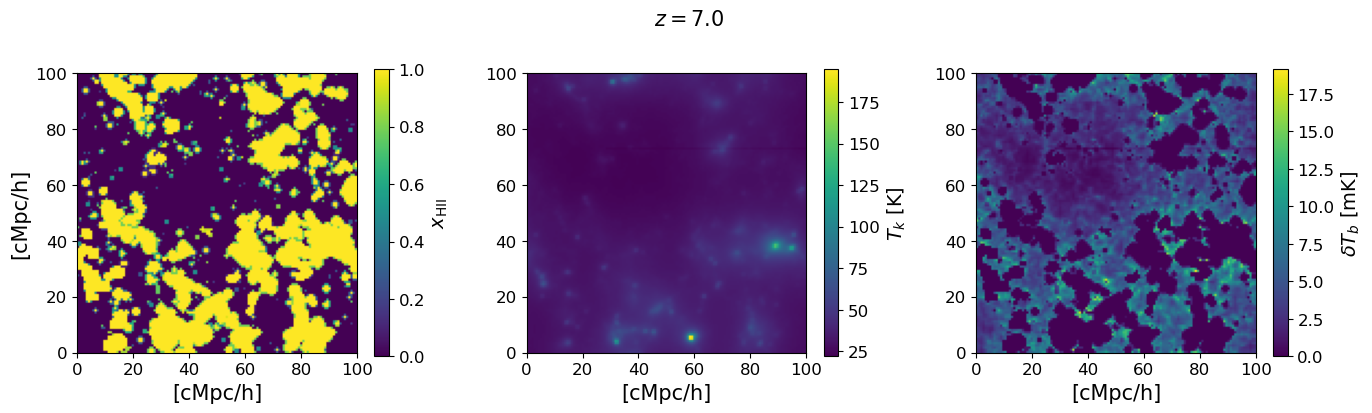

In [10]:
mz_index = np.argmin(np.abs(multi_z_quantities.z - z_target))
xHII_grid = multi_z_quantities.Grid_xHII[mz_index, ...]
dTb_grid  = multi_z_quantities.Grid_dTb[mz_index, ...]
Tk_grid   = multi_z_quantities.Grid_Temp[mz_index, ...]

mid = xHII_grid.shape[1] // 2
Lbox = parameters.simulation.Lbox  # cMpc/h
extent = [0, Lbox, 0, Lbox]

fig, axs = plt.subplots(1, 3, figsize=(14, 4))
for ax, grid, label in zip(axs,
                            [xHII_grid, Tk_grid, dTb_grid],
                            [r'$x_\mathrm{HII}$', r'$T_k$ [K]', r'$\delta T_b$ [mK]']):
    im = ax.imshow(grid[:, mid, :], origin='lower', cmap='viridis', extent=extent)
    ax.set_xlabel('[cMpc/h]', fontsize=15)
    fig.colorbar(im, ax=ax, label=label)
axs[0].set_ylabel('[cMpc/h]', fontsize=15)
fig.suptitle(f'$z={z_target}$', fontsize=15)
plt.tight_layout()
plt.show()

## 7. Global history and power spectra

The global (volume-averaged) signal summarises the overall evolution of reionization. We show the redshift evolution of the mean brightness temperature, gas temperature, and ionization fraction, as well as the 21-cm power spectrum amplitude at a fixed wavenumber $k$. These are the primary observational targets of radio telescopes such as SKA, HERA, and MWA.

Power spectrum:   0%|          | 0/25 [00:00<?, ?snapshot/s]

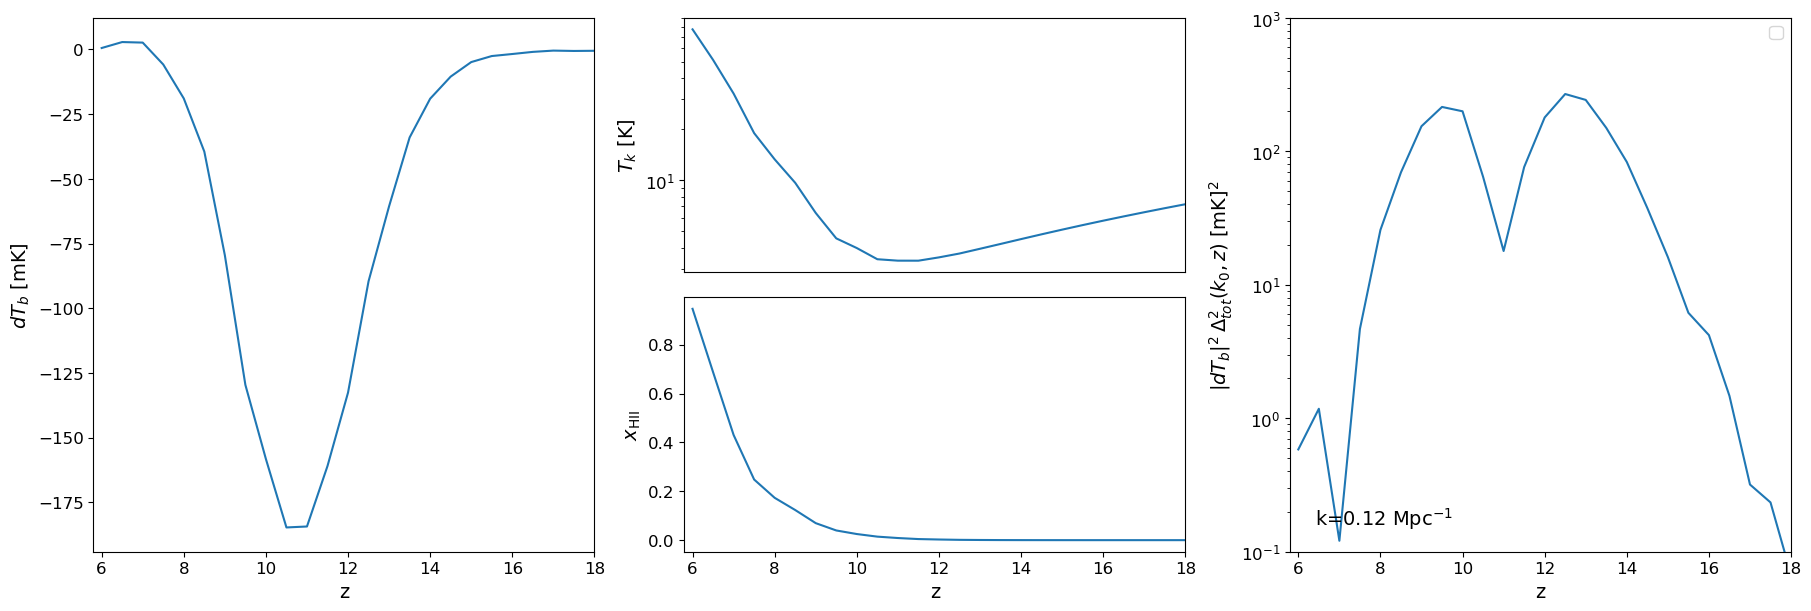

In [11]:
fig = plt.figure(constrained_layout=True, figsize=(18, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[:, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
ax4 = fig.add_subplot(gs[:, 2])

beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities)
beorn.plotting.draw_Temp_signal(ax2, multi_z_quantities)
beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities)
beorn.plotting.draw_dTb_power_spectrum_of_z(ax4, multi_z_quantities, parameters)

ax4.legend(loc='best')
ax2.axes.get_xaxis().set_visible(False)
plt.show()

## 8. Lightcone

A lightcone stitches together slices from different redshifts to mimic an actual observation: as we observe further into the past, the signal evolves. This is what a radio telescope effectively measures along the line of sight. The horizontal axis shows increasing redshift (earlier cosmic times) from right to left.

Making lightcone between 0.052632 < z < 0.142741


100%|██████████| 475/475 [00:00<00:00, 2929.82it/s]


...done


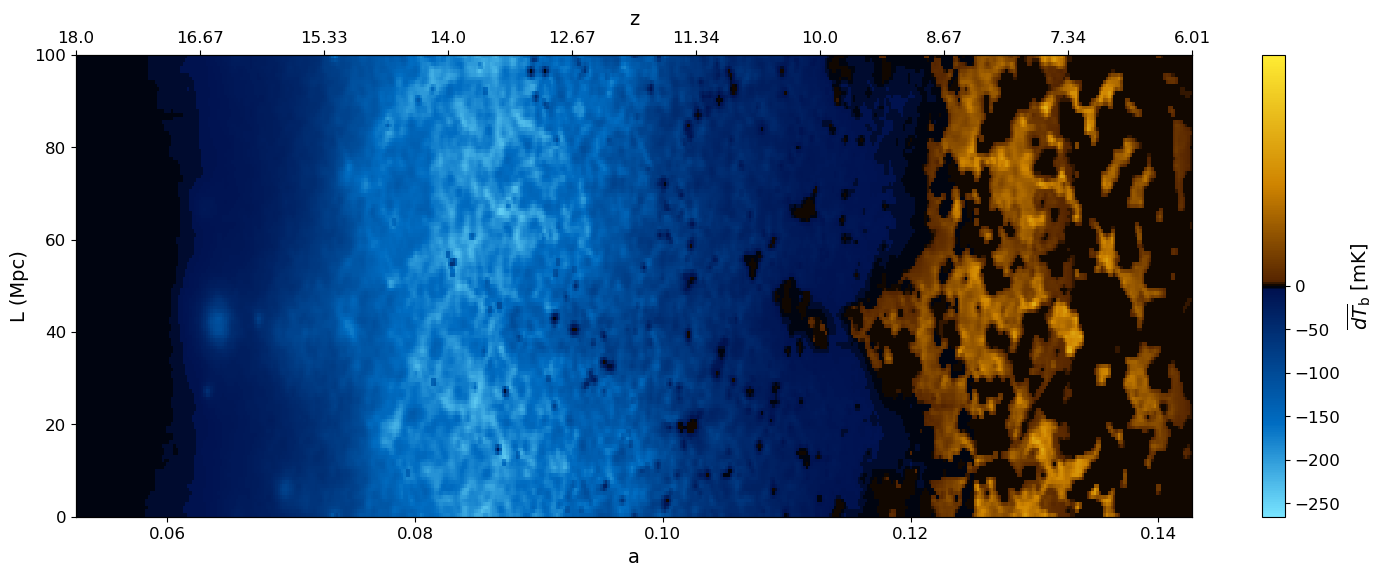

In [12]:
lightcone = beorn.structs.Lightcone.build(
    parameters,
    multi_z_quantities,
    quantity="Grid_dTb",
)

fig, ax = plt.subplots(figsize=(18, 6))
beorn.plotting.plot_lightcone(lightcone, ax, "", slice_number=30)
fig.show()